In [ ]:
### FUNCTIONS AND IMPORTS AND INIT 

from arcworld import transformations
import pandas as pd
import numpy as np
from scipy import ndimage
from arcworld.shapes.base import Shape


# Initialize generator with dummy config 
from arcworld.generator import Generator
config = {  ### This is dummy - won't actually be used.
    "min_n_shapes_per_grid": 2,
    "max_n_shapes_per_grid": 5,
    "n_examples": 4,
    "min_grid_size": 15,
    "max_grid_size": 20,
    "allowed_combinations": None,
    "allowed_transformations": ["crop_top_side", "translate_up", "translate_left", "mirror_horizontal", "rot90"],
    "min_transformation_depth": 2,
    "max_transformation_depth": 5,
    "shape_compulsory_conditionals": ["is_shape_less_than_6_rows", 
                                      "is_shape_less_than_6_cols"],
}
gen = Generator(config)


## Functions
def extract_objects(data, connectivity=8):
    """
    Extract connected components from a 2D array.
    
    Parameters:
        data: 2D numpy array
        connectivity: 4 or 8 (default 8)
    
    Returns:
        List of dictionaries, where each dictionary represents an object
        with {(row, col): value} pairs
    """
    if connectivity == 4:
        structure = np.array([[0, 1, 0], [1, 1, 1], [0, 1, 0]])
    else:
        structure = None  # Default 8-connectivity
    
    binary_mask = data != 0
    labeled_array, num_objects = ndimage.label(binary_mask, structure=structure)
    
    objects = []
    
    for obj_id in range(1, num_objects + 1):
        coords = np.where(labeled_array == obj_id)
        obj_dict = {}
        for row, col in zip(coords[0], coords[1]):
            obj_dict[(row, col)] = data[row, col]
        objects.append(Shape(obj_dict))
    
    return objects

def get_all_transformations_from_experiment(file):
    """
    Gets all unique transformation suites from a given experiment file.
    """
    dataset = pd.read_parquet(file).to_dict(orient="records")
    seen_transformations = []
    for data_point in dataset:
        transformation = data_point['transformation_suite'].tolist()
        if transformation not in seen_transformations:
            seen_transformations.append(transformation)
    return seen_transformations

# Start

In [ ]:
path_to_test = "../cogita-hf-new/COGITAO/CompGen/exp_setting_1/experiment_1"

#### ---------------------------------------------------- ####
#### STEP 0: Retrieve input example to be tested, corresponding GT output, and predicted output  
#### ---------------------------------------------------- ####
example_OOD = f"{path_to_test}/test_OOD.parquet"
OOD_file = pd.read_parquet(example_OOD).to_dict(orient="records")
example_idx = 20  # Index of the example to be tested
input = np.stack(OOD_file[example_idx]['input']) # Use np.stack to convert list of arrays to single array
gt_output = np.stack(OOD_file[example_idx]['output'])
task_id = np.stack(OOD_file[example_idx]['task_id'])
predicted = gt_output # Should be model_predict(input)




#### ---------------------------------------------------- ####
#### STEP 1: Retrieve all the possible transformation suites seen during training. 
#### ---------------------------------------------------- ####

# For every single Experiment Setting, we must first retrieve all the possible transformation suites seen during training. 
# This doesn't necessit to loop through the training set, as the test (non OOD) set contains all the possible transformation suites.
example_training = f"{path_to_test}/test.parquet"
transformation_list = get_all_transformations_from_experiment(example_training)
print(f"Transformations seen during training: {transformation_list}")


#### ---------------------------------------------------- ####
#### STEP 2: Apply all transformations seen during training to the tested example
#### ---------------------------------------------------- ####

# Before applying the transformations, we must first extract the objects from the input grid.
objects = extract_objects(input)

# Convert the Objects 

# Now, we can loop through all the transformation suites seen during training, apply them to the input grid, and store the resulting grids.
all_possible_grids_from_ID_training = []
for transformation_suite in transformation_list:
    try:
        output_grid, full_grid_sequence = gen.apply_transform_suite_to_grid_2(transformation_suite, input, objects)
        all_possible_grids_from_ID_training.append(output_grid)
    except Exception as e:
        continue

#### ---------------------------------------------------- ####
#### STEP 3: Verify if the predicted output matches any of the possible grids obtained from applying the training transformations
#### ---------------------------------------------------- ####
            
match_found = False
for possible_grid in all_possible_grids_from_ID_training:
    if np.array_equal(possible_grid, predicted):
        match_found = True
        break
    


Transformations seen during training: [['translate_up'], ['rot90'], ['mirror_horizontal'], ['translate_up', 'translate_up'], ['rot90', 'rot90'], ['mirror_horizontal', 'mirror_horizontal'], ['translate_up', 'mirror_horizontal'], ['rot90', 'mirror_horizontal'], ['mirror_horizontal', 'rot90']]


# Verifying that things work...

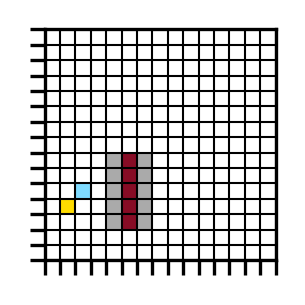

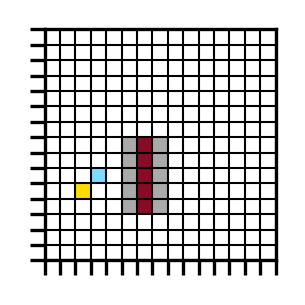

In [26]:
from arcworld.general_utils import plot_grid
plot_grid(input, size = (1,1))
output_grid, full_grid_sequence = gen.apply_transform_suite_to_grid_2(["translate_up", "translate_right"], input, objects)
# plot_grid(gt_output, size = (1,1))
plot_grid(output_grid, size = (1,1))

# Now loop and save everything

In [ ]:
folders = [
    "../cogita-hf-new/COGITAO/supplementary/CompGen_Scaling/exp_setting_1/experiment_0_100K"
    "../cogita-hf-new/COGITAO/supplementary/CompGen_Scaling/exp_setting_2/experiment_0_100K"
    "../cogita-hf-new/COGITAO/supplementary/CompGen_Scaling/exp_setting_2/experiment_0_100K"

    "../cogita-hf-new/COGITAO/supplementary/CompGen_Scaling/exp_setting_1/experiment_1_100K"
    "../cogita-hf-new/COGITAO/supplementary/CompGen_Scaling/exp_setting_2/experiment_1_100K"
    "../cogita-hf-new/COGITAO/supplementary/CompGen_Scaling/exp_setting_2/experiment_1_100K"
]

In [32]:
import pandas as pd
import numpy as np
import json
import os
from pathlib import Path

# Import your custom modules (assuming they exist in the project)
# from your_module import get_all_transformations_from_experiment, extract_objects, gen

# Placeholder imports - replace with actual imports
# import gen
# from transformations import get_all_transformations_from_experiment
# from object_extraction import extract_objects

folders = [
    "../cogita-hf-new/COGITAO/supplementary/CompGen_Scaling/exp_setting_1/experiment_0_100K",
    "../cogita-hf-new/COGITAO/supplementary/CompGen_Scaling/exp_setting_2/experiment_0_100K",
    "../cogita-hf-new/COGITAO/supplementary/CompGen_Scaling/exp_setting_3/experiment_0_100K",  # Fixed: was duplicate of exp_setting_2
    "../cogita-hf-new/COGITAO/supplementary/CompGen_Scaling/exp_setting_1/experiment_1_100K",
    "../cogita-hf-new/COGITAO/supplementary/CompGen_Scaling/exp_setting_2/experiment_1_100K",
    "../cogita-hf-new/COGITAO/supplementary/CompGen_Scaling/exp_setting_3/experiment_1_100K",  # Fixed: was duplicate of exp_setting_2
]


def numpy_to_list(obj):
    """Convert numpy arrays to lists for JSON serialization."""
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    elif isinstance(obj, dict):
        return {k: numpy_to_list(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [numpy_to_list(item) for item in obj]
    else:
        return obj


def process_folder(path_to_test):
    """
    Process a single folder: retrieve OOD test data, apply transformations,
    and return results organized by task_key.
    """
    print(f"\n{'='*60}")
    print(f"Processing folder: {path_to_test}")
    print(f"{'='*60}")
    
    # Check if folder exists
    if not os.path.exists(path_to_test):
        print(f"WARNING: Folder does not exist: {path_to_test}")
        return None
    
    #### ---------------------------------------------------- ####
    #### STEP 0: Load OOD test file
    #### ---------------------------------------------------- ####
    example_OOD = f"{path_to_test}/test_OOD.parquet"
    
    if not os.path.exists(example_OOD):
        print(f"WARNING: OOD file does not exist: {example_OOD}")
        return None
    
    OOD_file = pd.read_parquet(example_OOD).to_dict(orient="records")
    print(f"Loaded {len(OOD_file)} examples from OOD test file")
    
    #### ---------------------------------------------------- ####
    #### STEP 1: Retrieve all possible transformation suites seen during training
    #### ---------------------------------------------------- ####
    example_training = f"{path_to_test}/test.parquet"
    
    if not os.path.exists(example_training):
        print(f"WARNING: Training test file does not exist: {example_training}")
        return None
    
    transformation_list = get_all_transformations_from_experiment(example_training)
    print(f"Found {len(transformation_list)} transformation suites seen during training")
    
    #### ---------------------------------------------------- ####
    #### STEP 2 & 3: Loop through all examples and process each
    #### ---------------------------------------------------- ####
    results_by_task_key = {}
    
    for example_idx in range(len(OOD_file)):
        try:
            # Extract data for this example
            input_grid = np.stack(OOD_file[example_idx]['input'])
            gt_output = np.stack(OOD_file[example_idx]['output'])
            task_key = OOD_file[example_idx]['task_key']
            
            # Convert task_key to string if it's a numpy array
            if isinstance(task_key, np.ndarray):
                task_key = str(task_key)
            
            # Extract objects from input grid
            objects = extract_objects(input_grid)
            
            # Apply all transformations seen during training
            all_possible_grids_from_ID_training = []
            for transformation_suite in transformation_list:
                try:
                    output_grid, full_grid_sequence = gen.apply_transform_suite_to_grid_2(
                        transformation_suite, input_grid, objects
                    )
                    all_possible_grids_from_ID_training.append(output_grid)
                except Exception as e:
                    continue
            
            # Store results for this task_key
            results_by_task_key[str(task_key)] = {
                "input": input_grid,
                "gt_output": gt_output,
                "all_possible_grids_from_ID_training": all_possible_grids_from_ID_training
            }
            
            if (example_idx + 1) % 10 == 0:
                print(f"Processed {example_idx + 1}/{len(OOD_file)} examples...")
                
        except Exception as e:
            print(f"Error processing example {example_idx}: {e}")
            continue
    
    print(f"Successfully processed {len(results_by_task_key)} tasks")
    return results_by_task_key


def save_results_to_json(results, path_to_test, output_filename="transformation_results.json"):
    """
    Save results to a JSON file in the folder.
    Converts numpy arrays to lists for JSON serialization.
    """
    if results is None:
        return
    
    # Convert all numpy arrays to lists
    results_serializable = numpy_to_list(results)
    
    path = path_to_test.split("CompGen_Scaling/")[-1].replace("/", "_")

    output_path = os.path.join("data_for_klim", path + "_" + output_filename)
    
    with open(output_path, 'w') as f:
        json.dump(results_serializable, f, indent=2)
    
    print(f"Results saved to: {output_path}")


def main():
    """Main function to process all folders."""
    print("Starting processing of all folders...")
    print(f"Total folders to process: {len(folders)}")
    
    for folder in folders:
        try:
            # Process the folder
            results = process_folder(folder)
            
            # Save results to JSON
            if results is not None:
                save_results_to_json(results, folder)
            
        except Exception as e:
            print(f"ERROR processing folder {folder}: {e}")
            continue
    
    print("\n" + "="*60)
    print("All folders processed!")
    print("="*60)


if __name__ == "__main__":
    main()

Starting processing of all folders...
Total folders to process: 6

Processing folder: ../cogita-hf-new/COGITAO/supplementary/CompGen_Scaling/exp_setting_1/experiment_0_100K
Loaded 1000 examples from OOD test file
Found 18 transformation suites seen during training
Processed 10/1000 examples...
Processed 20/1000 examples...
Processed 30/1000 examples...
Processed 40/1000 examples...
Processed 50/1000 examples...
Processed 60/1000 examples...
Processed 70/1000 examples...
Processed 80/1000 examples...
Processed 90/1000 examples...
Processed 100/1000 examples...
Processed 110/1000 examples...
Processed 120/1000 examples...
Processed 130/1000 examples...
Processed 140/1000 examples...
Processed 150/1000 examples...
Processed 160/1000 examples...
Processed 170/1000 examples...
Processed 180/1000 examples...
Processed 190/1000 examples...
Processed 200/1000 examples...
Processed 210/1000 examples...
Processed 220/1000 examples...
Processed 230/1000 examples...
Processed 240/1000 examples...


In [37]:
x = [[0,0,0], 
     [1,2,2], 
     [0,0,0]]

y = [[0,0,0], 
     [0,2,2], 
     [0,3,0]]

# Compute the error of all the non-zero pixels

wrong = 0
for i in range(3):
    for j in range(3):
        if x[i][j] == 0 and y[i][j] == 0:
            continue
        elif y[i][j] != x[i][j]:
            wrong += 1

print(wrong)
print("error:", wrong / (len(x) * len(x[0])))

2
error: 0.2222222222222222
